# scaling laws

Graphs in Kaplan are superb, i can't do it justice
- https://arxiv.org/abs/2001.08361 (Kaplan)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

1. Model performance $\propto$ scale, weakly on model shape
- N - number of parameters
- D - size of dataset
- C - amount of compute

plotted log-log plots

In [16]:
N = np.logspace(3, 9, 20)
N_test_loss = (N / 8.8e13)**-0.076 #### GOLDEN Formula they found

D = np.logspace(7, 9, 20)
D_test_loss = (D / 5.4e13)**-0.095 #### GOLDEN Formula they found

C = np.logspace(-9, 1, 20)
C_test_loss = (C / 2.3e8)**-0.05 #### GOLDEN Formula they found

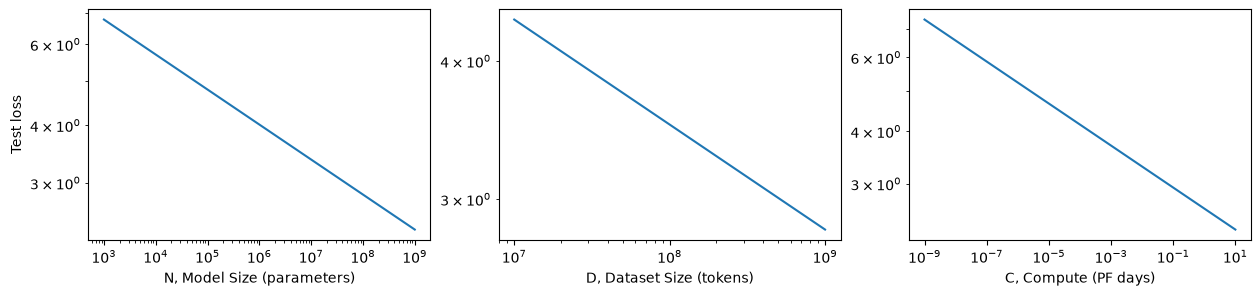

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3))

ax[0].plot(N, N_test_loss)
ax[0].set_xlabel("N, Model Size (parameters)")
ax[0].set_ylabel("Test loss")
ax[0].set_xscale("log")
ax[0].set_yscale("log")

ax[1].plot(D, D_test_loss)
ax[1].set_xlabel("D, Dataset Size (tokens)")
ax[1].set_xscale("log")
ax[1].set_yscale("log")

ax[2].plot(C, C_test_loss)
ax[2].set_xlabel("C, Compute (PF days)")
ax[2].set_xscale("log")
ax[2].set_yscale("log")

plt.show()

2. **smooth power laws**
- $L = (N_c / N)^{\alpha_N}$
- $L = (D_c / D)^{\alpha_D}$
- $L = (C_c / C)^{\alpha_C}$

aka $ L \propto 1/X^{\alpha_X}, X \in \{N, D, C\} $

3. **Universality of overfitting**

overfitting when N or D don't scale with each other (assuming unlimited C). aka even overfitting is predictable.

Perf penalty = $N/ D^{0.74}$. -- this is wrong, see Chinchilla paper.

4. **Universality of training**
- training curves = power law curves.
- makes loss predictable

5. **Transfer improves with test performance**
- training perf $\propto$ test perf
- constant offset in loss in test dataset

6. **sample efficiency**
- bigger = more sample-efficient

needs less data, less optimizer steps to reach same loss (fig 2 rainbow curves)

7. **convergence is inefficient**
- big models don't even need to converge to beat small models

$D \sim C^{0.27}$ requirements for convergence -- Chinchilla proves this wrong later.

- with fixed C. you can just make N really big and stop short of convergence.


8. **Optimal batch size**
- read McCandlish paper (Large-Batch Training)

----

some other relationships curve fitted to their data:

$L(N,D) = \left[ \frac{N_c}{N}^{\alpha_N} + \frac{D_c}{D} \right]^{\alpha_D}$

---

$L(N,S) = \frac{N_c}{N}^{\alpha_N} + \frac{S_c}{S}^{\alpha_S}$

